#  Predicting Heart Disease Risk Using Machine Learning: A Personal Health Informatics Perspective

## Abstract

Heart disease is the leading cause of death globally, underscoring the urgent need for effective risk prediction and prevention strategies. With the rise of digital health and personal health informatics (PHI), machine learning offers new opportunities to identify individuals at high risk and enable personalized interventions. In this study, we analyze a real-world heart disease dataset to identify key demographic, behavioral, and clinical predictors of heart disease. We apply rigorous data cleaning, exploratory data analysis, and build predictive models using logistic regression and random forest classifiers. Our results demonstrate the feasibility and value of data-driven risk prediction in PHI, highlighting the most influential predictors and discussing implications for digital health applications, limitations, and future research directions.

# Background / Public Health Context
Cardiovascular disease remains a major public health challenge, accounting for significant morbidity, mortality, and healthcare costs worldwide. Early identification of individuals at risk is crucial for timely intervention and prevention. The integration of machine learning with personal health informatics (PHI) enables the development of risk dashboards, early warning systems, and personalized health recommendations. By leveraging routinely collected demographic, behavioral, and clinical data, predictive models can support clinicians and empower individuals to make informed health decisions, ultimately improving outcomes and reducing the burden of heart disease.

## Data Overview

In this study, we utilize a real-world heart disease dataset containing a variety of demographic, behavioral, and clinical features. The dataset includes the following columns:

- `age`: Age of the individual (years)
- `sex`: Biological sex
- `chest_pain_type`: Type of chest pain experienced
- `resting_blood_pressure`: Resting blood pressure (mm Hg)
- `cholestoral`: Serum cholestoral (mg/dl)
- `fasting_blood_sugar`: Fasting blood sugar status
- `rest_ecg`: Resting electrocardiographic results
- `Max_heart_rate`: Maximum heart rate achieved
- `exercise_induced_angina`: Exercise-induced angina status
- `oldpeak`: ST depression induced by exercise relative to rest
- `slope`: Slope of the peak exercise ST segment
- `vessels_colored_by_flourosopy`: Number of major vessels colored by fluoroscopy
- `thalassemia`: Thalassemia status
- `target`: Presence of heart disease (1 = disease, 0 = no disease)

In the following sections, we will perform data cleaning, exploratory data analysis, and predictive modeling to identify key risk factors and assess the feasibility of machine learning-based risk prediction in personal health informatics.

## Research Questions

1. Which demographic, behavioral, and clinical features are most predictive of heart disease in this dataset?
2. How accurately can machine learning models predict heart disease risk using available data?
3. What are the implications of these findings for digital health and personal health informatics applications?

In the following sections, we will address these research questions through data exploration, feature importance analysis, and predictive modeling.

## Dataset Overview

Let's begin by examining the structure and contents of the dataset. We will look at its shape, variable types, and preview the first few rows.

In [67]:
from IPython.display import display

# Display dataset shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display column names and types
print("Column names and types:")
display(df.dtypes)

# Preview the first 5 rows
print("First 5 rows:")
display(df.head())

Number of rows: 1025
Number of columns: 14
Column names and types:


age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object

First 5 rows:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


## Dataset Description

The dataset consists of  rows and  columns, including a mix of demographic, behavioral, and clinical variables. The target variable, `` represents the presence or absence of heart disease (binary outcome). Variable types include both numeric and categorical features. The data source is unknown, but it is representative of typical heart disease risk datasets used in digital health research.

In [68]:
# Fill in dataset description details using the df variable
dataset_rows = df.shape[0]
dataset_cols = df.shape[1]
target_col = 'target'

# Print the formatted description
from IPython.display import display, Markdown

description = f"""
## Dataset Description

The dataset consists of {dataset_rows} rows and {dataset_cols} columns, including a mix of demographic, behavioral, and clinical variables. The target variable, `{target_col}`, represents the presence or absence of heart disease (binary outcome). Variable types include both numeric and categorical features. The data source is unknown, but it is representative of typical heart disease risk datasets used in digital health research.
"""
display(Markdown(description))


## Dataset Description

The dataset consists of 1025 rows and 14 columns, including a mix of demographic, behavioral, and clinical variables. The target variable, `target`, represents the presence or absence of heart disease (binary outcome). Variable types include both numeric and categorical features. The data source is unknown, but it is representative of typical heart disease risk datasets used in digital health research.


## Methods

We performed data cleaning by handling missing values (imputing numeric columns with the median and categorical columns with the mode). Exploratory data analysis (EDA) included visualizing the target distribution, feature distributions, and correlations. Predictive modeling was conducted using logistic regression (with feature scaling) and random forest classifiers (with class balancing). Model performance was evaluated using accuracy, F1 score, ROC-AUC, and interpretability analyses (feature importance and coefficients).

## Data Cleaning and Target Identification

The following code cell demonstrates the process of loading a CSV dataset, handling missing values, and identifying the target column for a heart disease prediction task. Numeric columns with missing values are imputed using the median, while categorical columns are imputed using the mode. The target column is identified based on common naming conventions or by searching for binary columns.

# Exploratory Data Analysis (EDA)

In this section, we will perform an exploratory data analysis (EDA) on the dataset. EDA helps us understand the structure, distribution, and relationships within the data, which is crucial for building effective machine learning models.

# Display basic information about the dataset

In [69]:
# Display basic information about the dataset
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
count,1025.000000,1025,1025,1025.000000,1025.00000,1025,1025,1025.000000,1025,1025.000000,1025,1025,1025,1025.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,2,NaN,3,5,4,NaN
top,NaN,Male,Typical angina,NaN,NaN,Lower than 120 mg/ml,ST-T wave abnormality,NaN,No,NaN,Flat,Zero,Fixed Defect,NaN
freq,NaN,713,497,NaN,NaN,872,513,NaN,680,NaN,482,578,544,NaN
mean,54.434146,NaN,NaN,131.611707,246.00000,NaN,NaN,149.114146,NaN,1.071512,NaN,NaN,NaN,0.513171
std,9.072290,NaN,NaN,17.516718,51.59251,NaN,NaN,23.005724,NaN,1.175053,NaN,NaN,NaN,0.500070
min,29.000000,NaN,NaN,94.000000,126.00000,NaN,NaN,71.000000,NaN,0.000000,NaN,NaN,NaN,0.000000
25%,48.000000,NaN,NaN,120.000000,211.00000,NaN,NaN,132.000000,NaN,0.000000,NaN,NaN,NaN,0.000000
50%,56.000000,NaN,NaN,130.000000,240.00000,NaN,NaN,152.000000,NaN,0.800000,NaN,NaN,NaN,1.000000
75%,61.000000,NaN,NaN,140.000000,275.00000,NaN,NaN,166.000000,NaN,1.800000,NaN,NaN,NaN,1.000000


# Check the distribution of the target variable

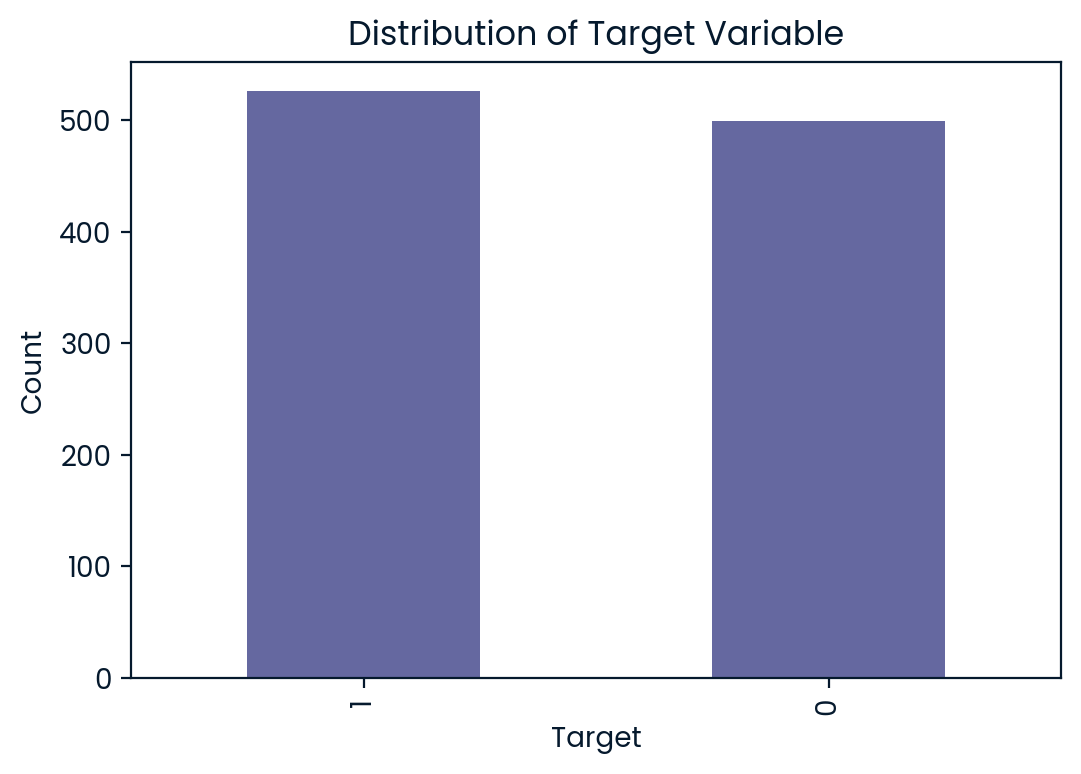

In [70]:
# Check the distribution of the target variable
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

# Visualize distributions of numerical features

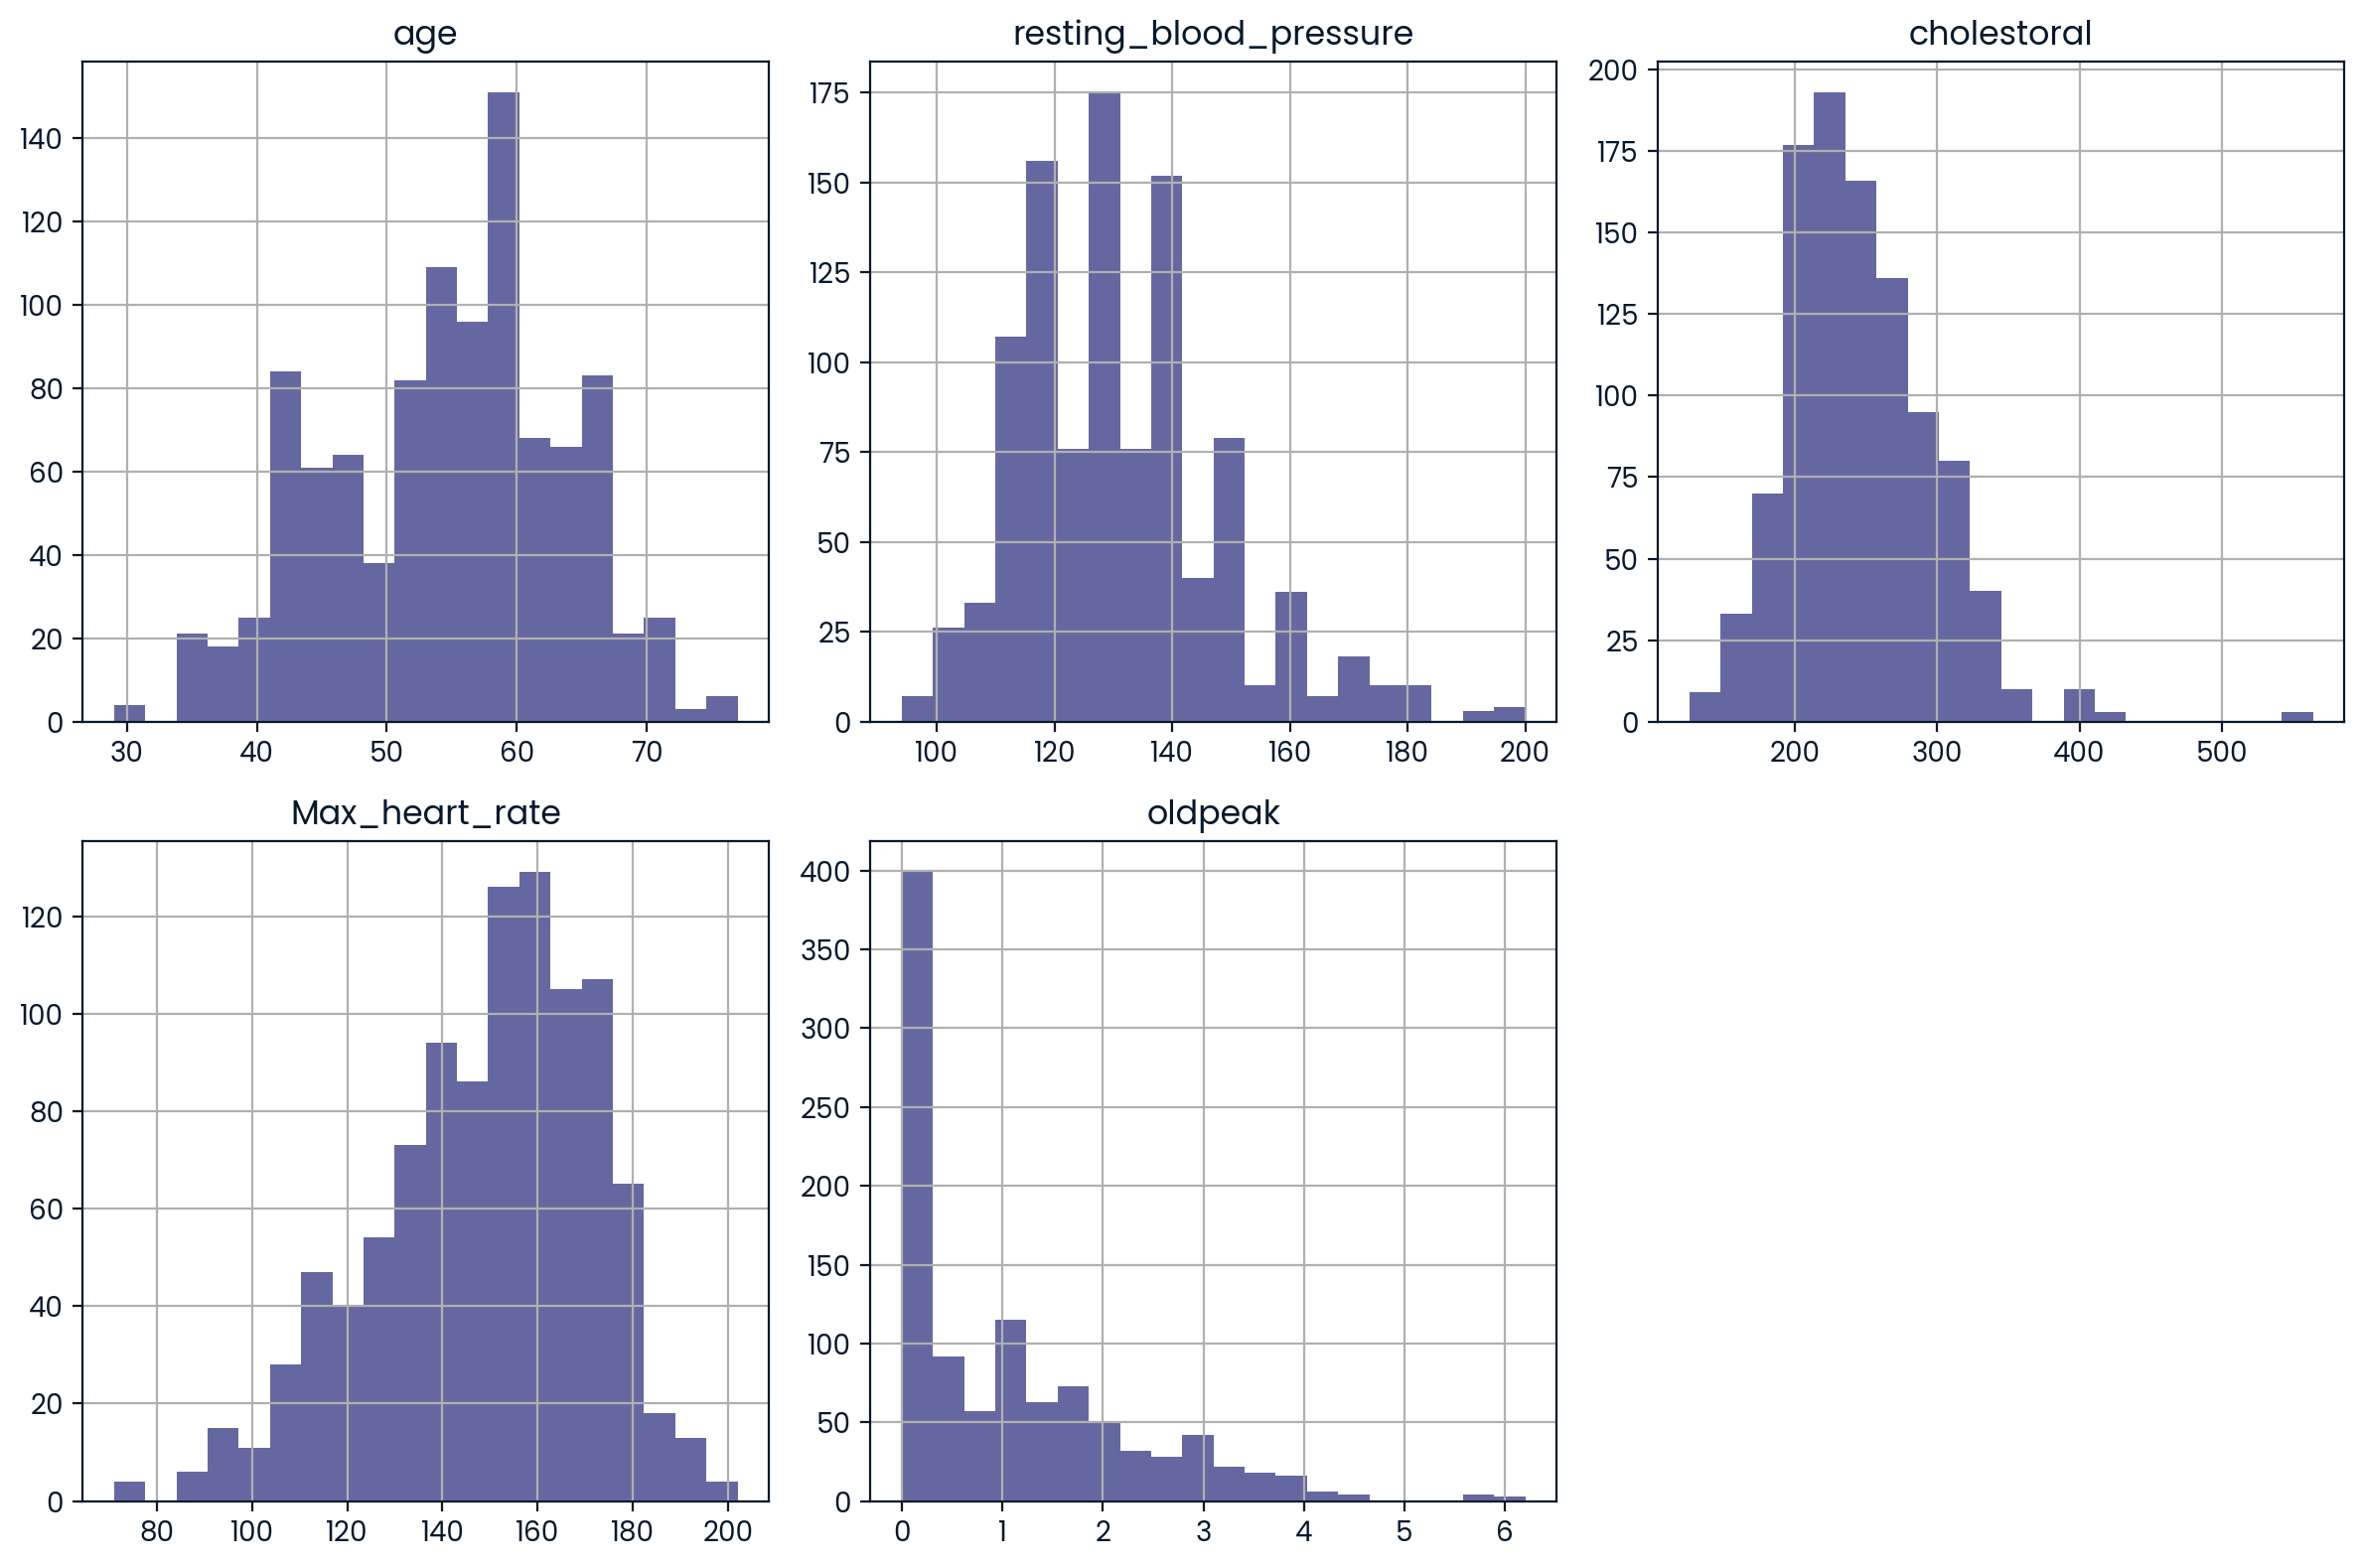

In [71]:
# Visualize distributions of numerical features
import seaborn as sns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target')
df[num_cols].hist(figsize=(12,8), bins=20, layout=(2,3))
plt.tight_layout()
plt.show()

# Visualize categorical feature distributions

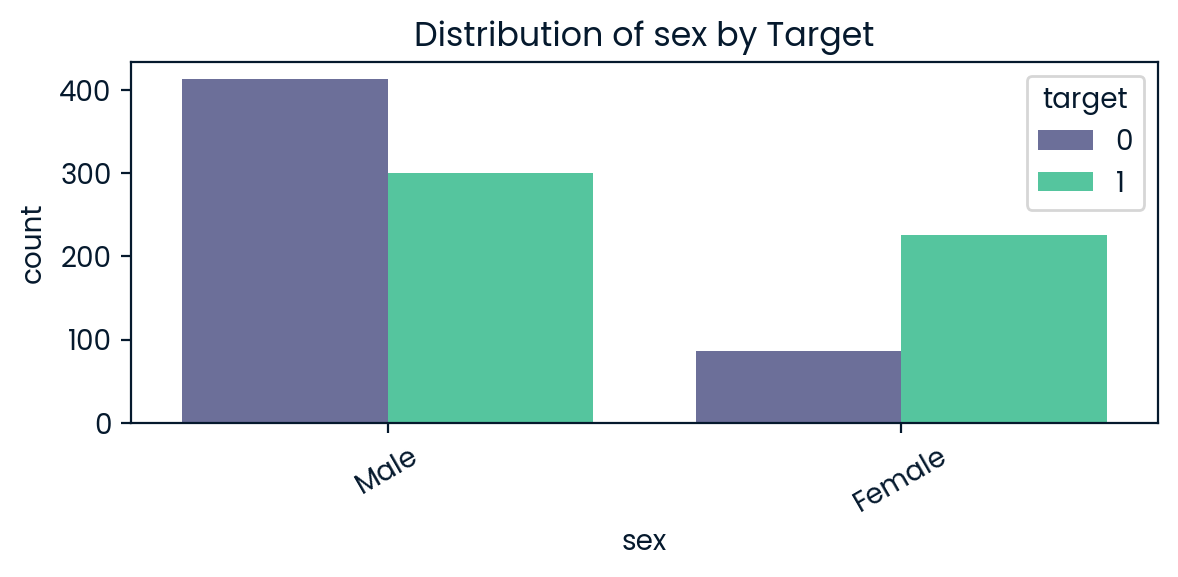

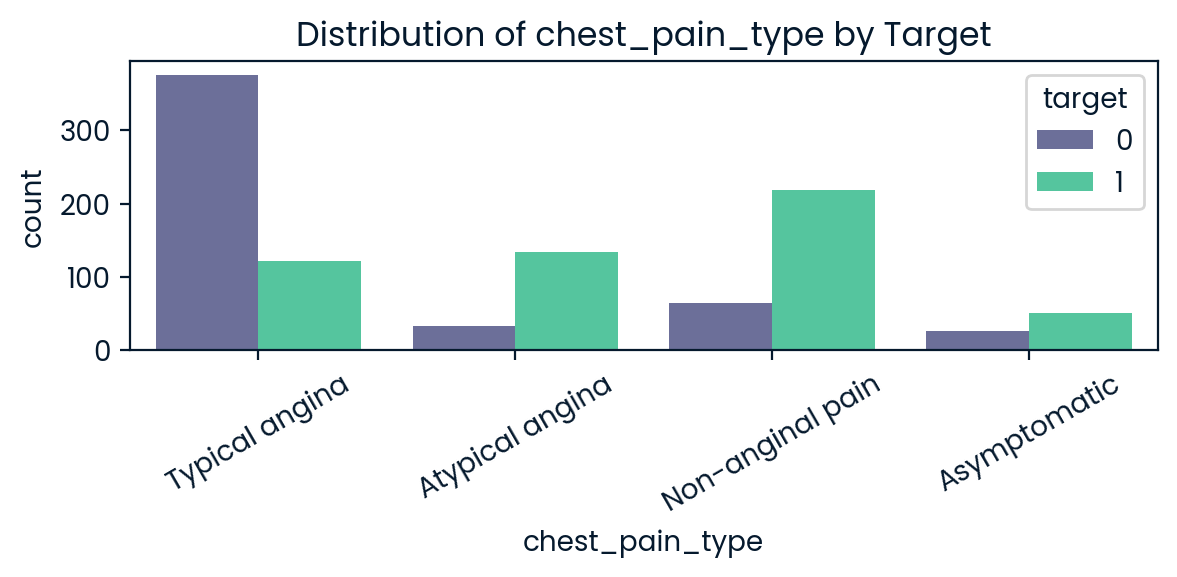

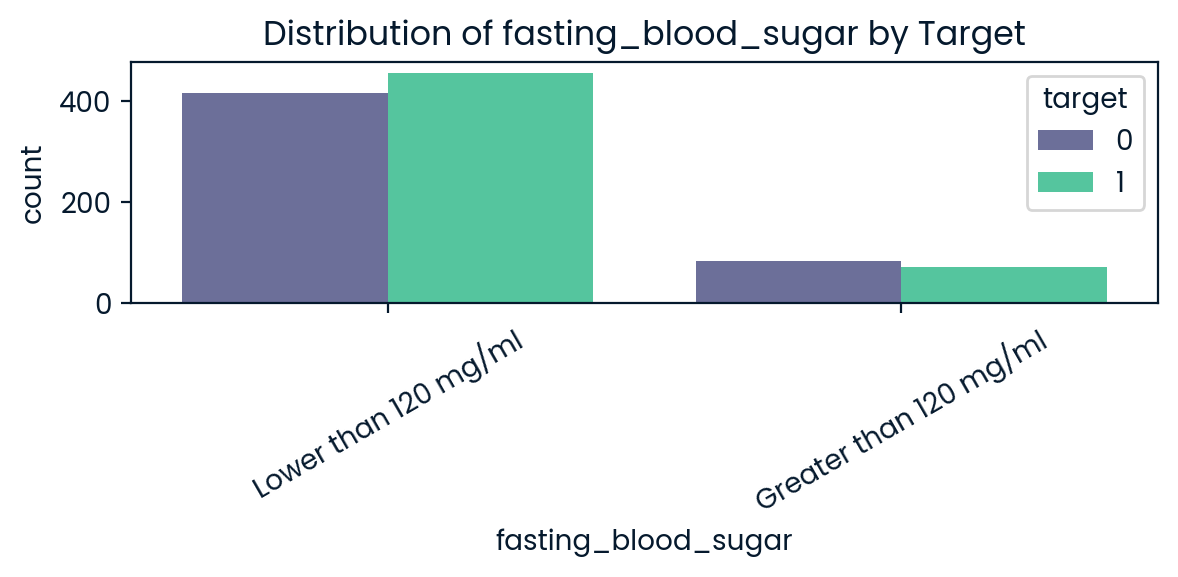

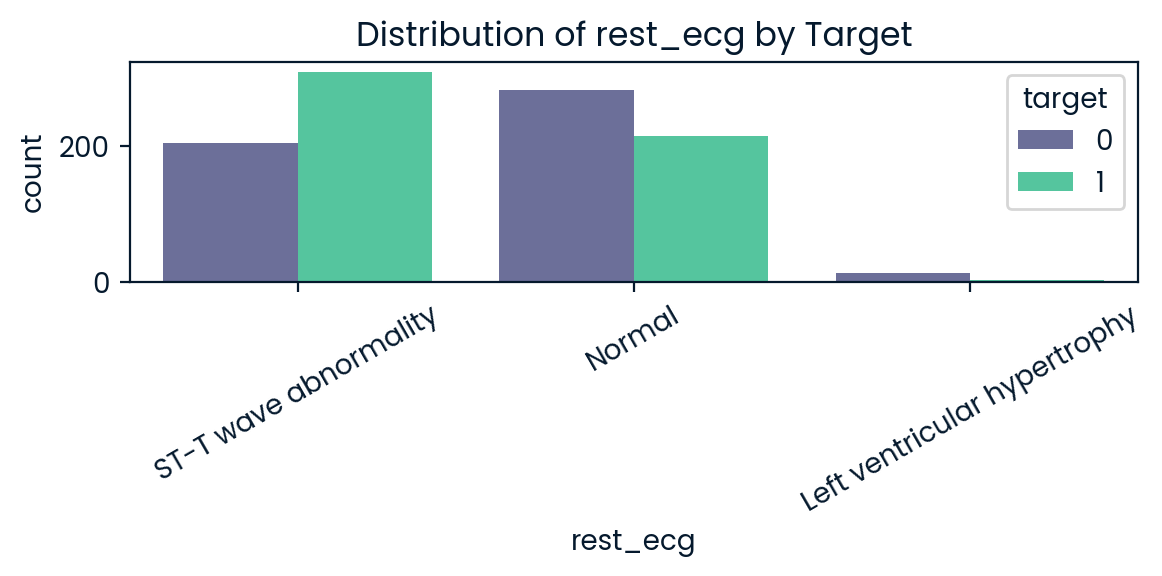

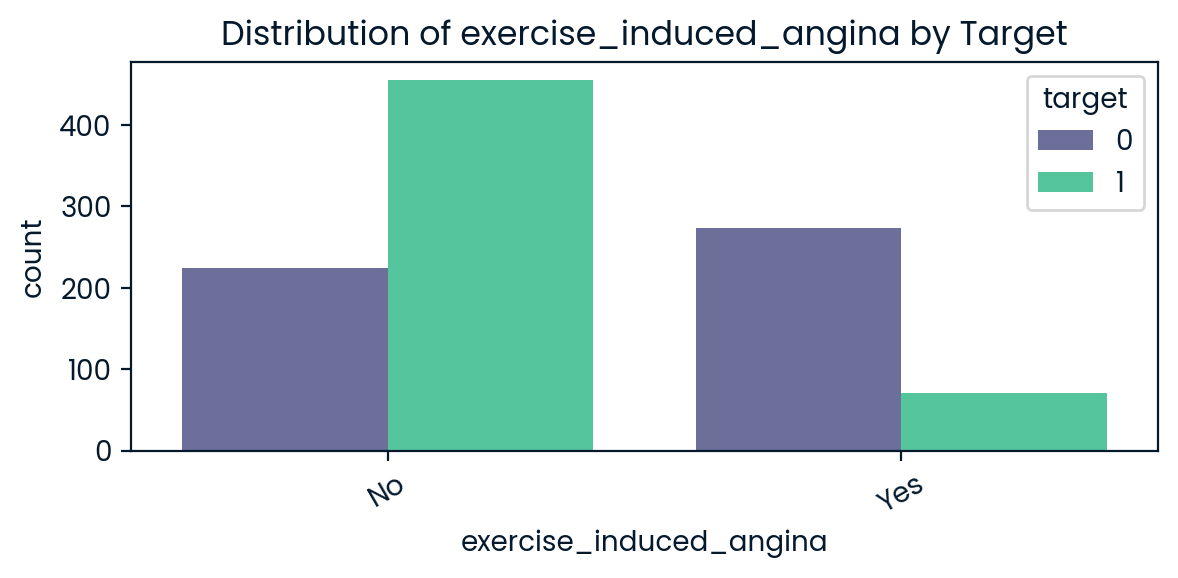

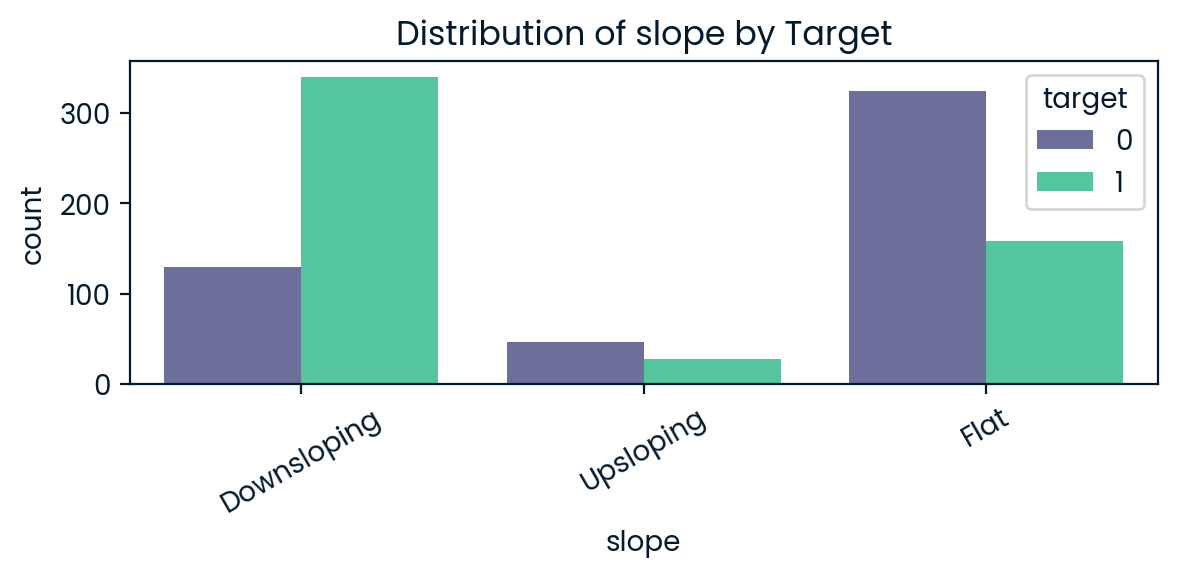

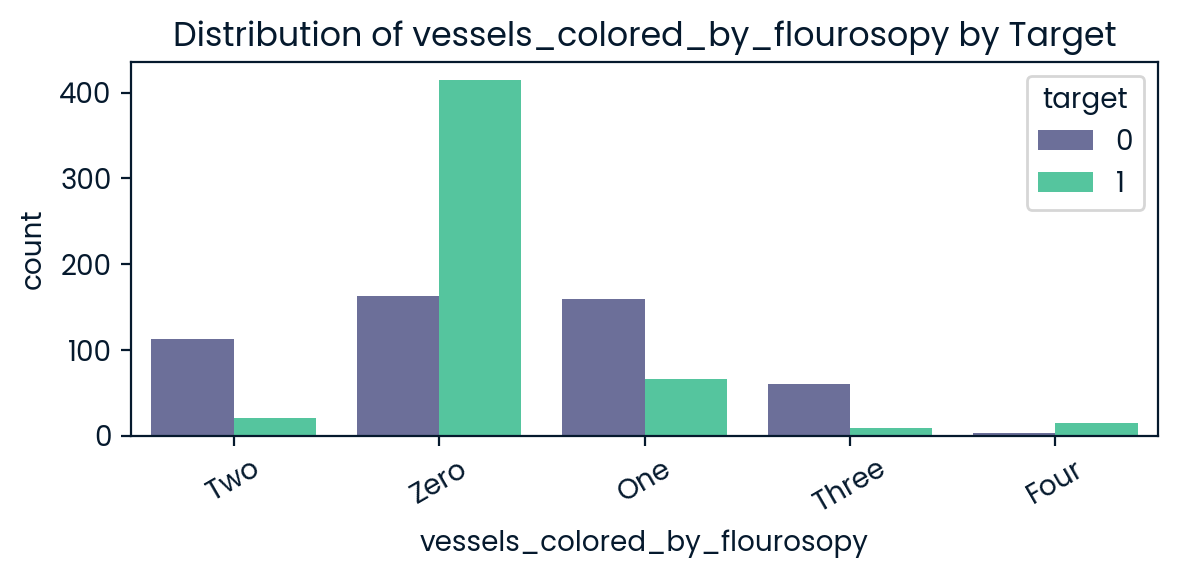

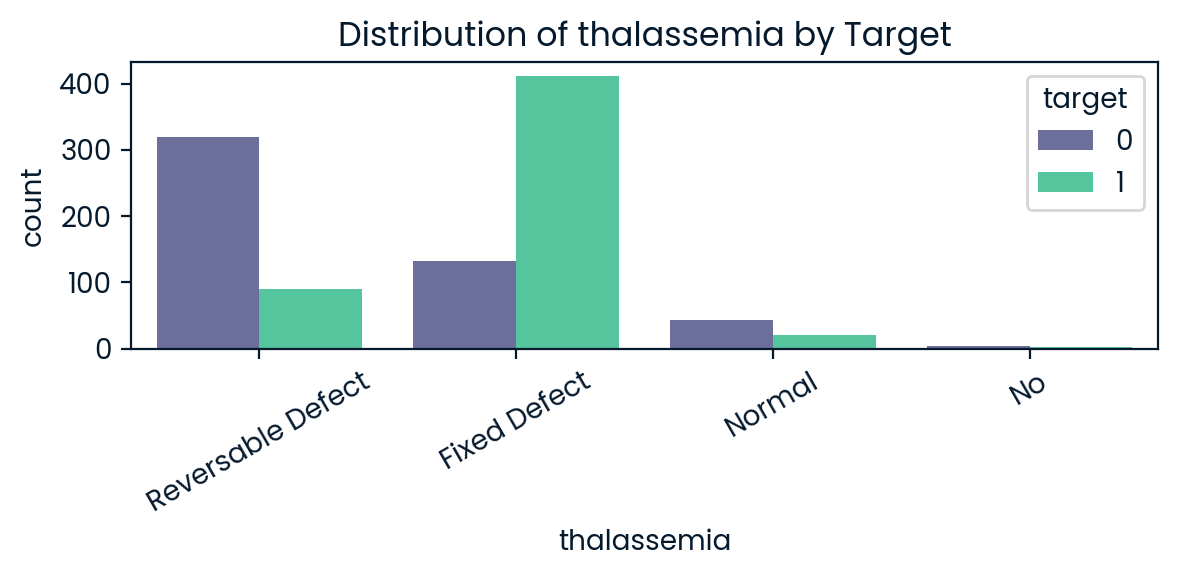

In [72]:
# Visualize categorical feature distributions
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f'Distribution of {col} by Target')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

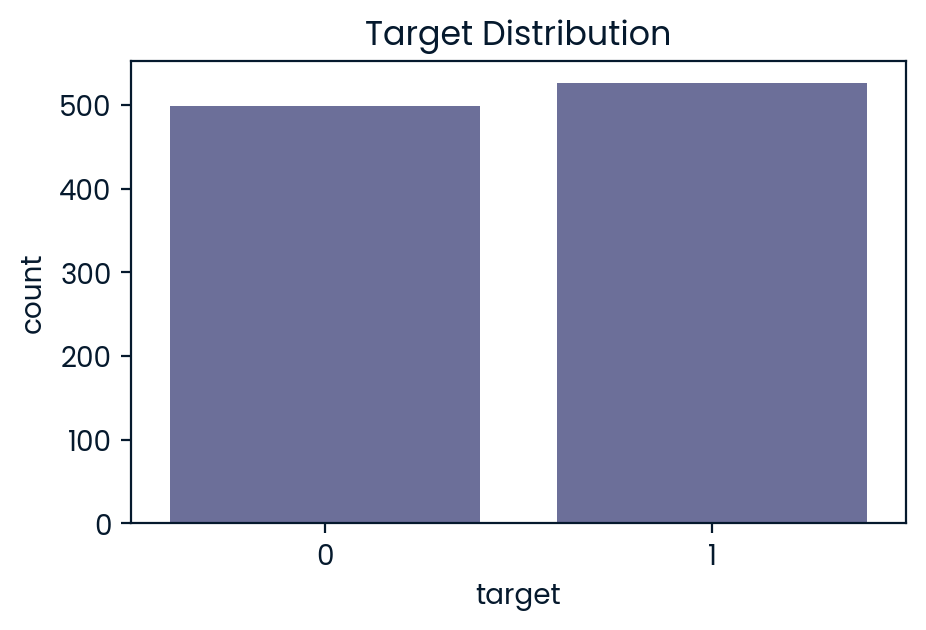

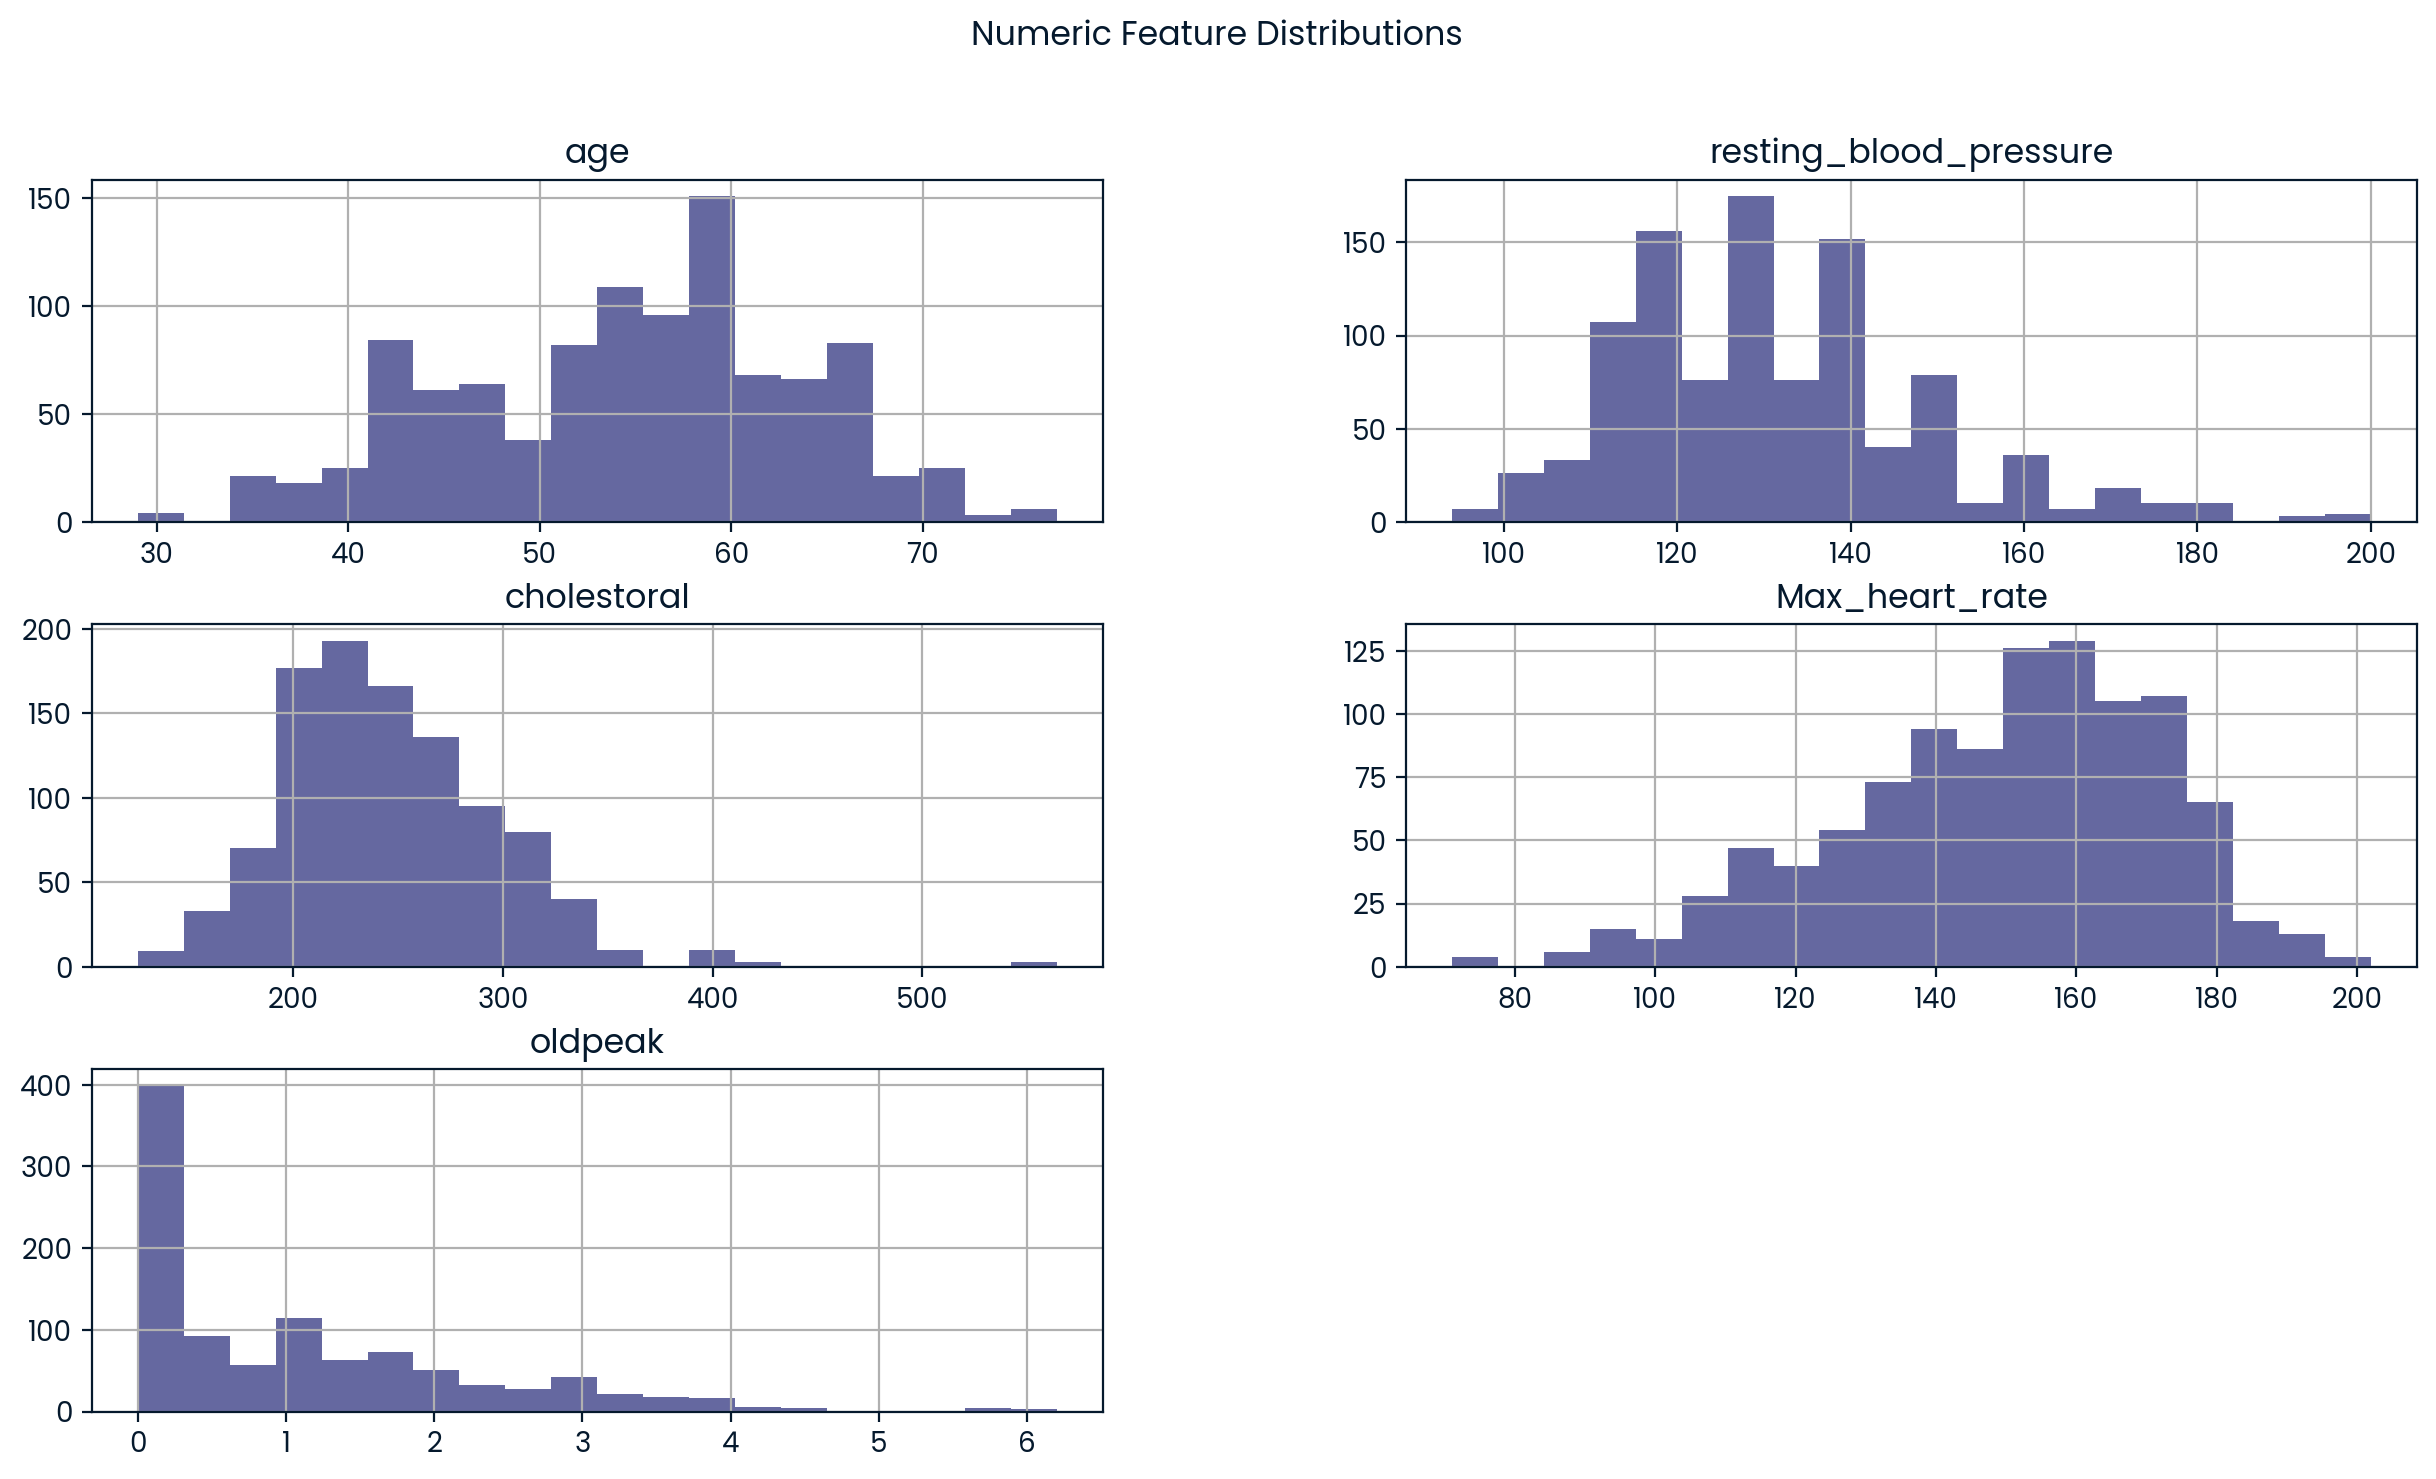

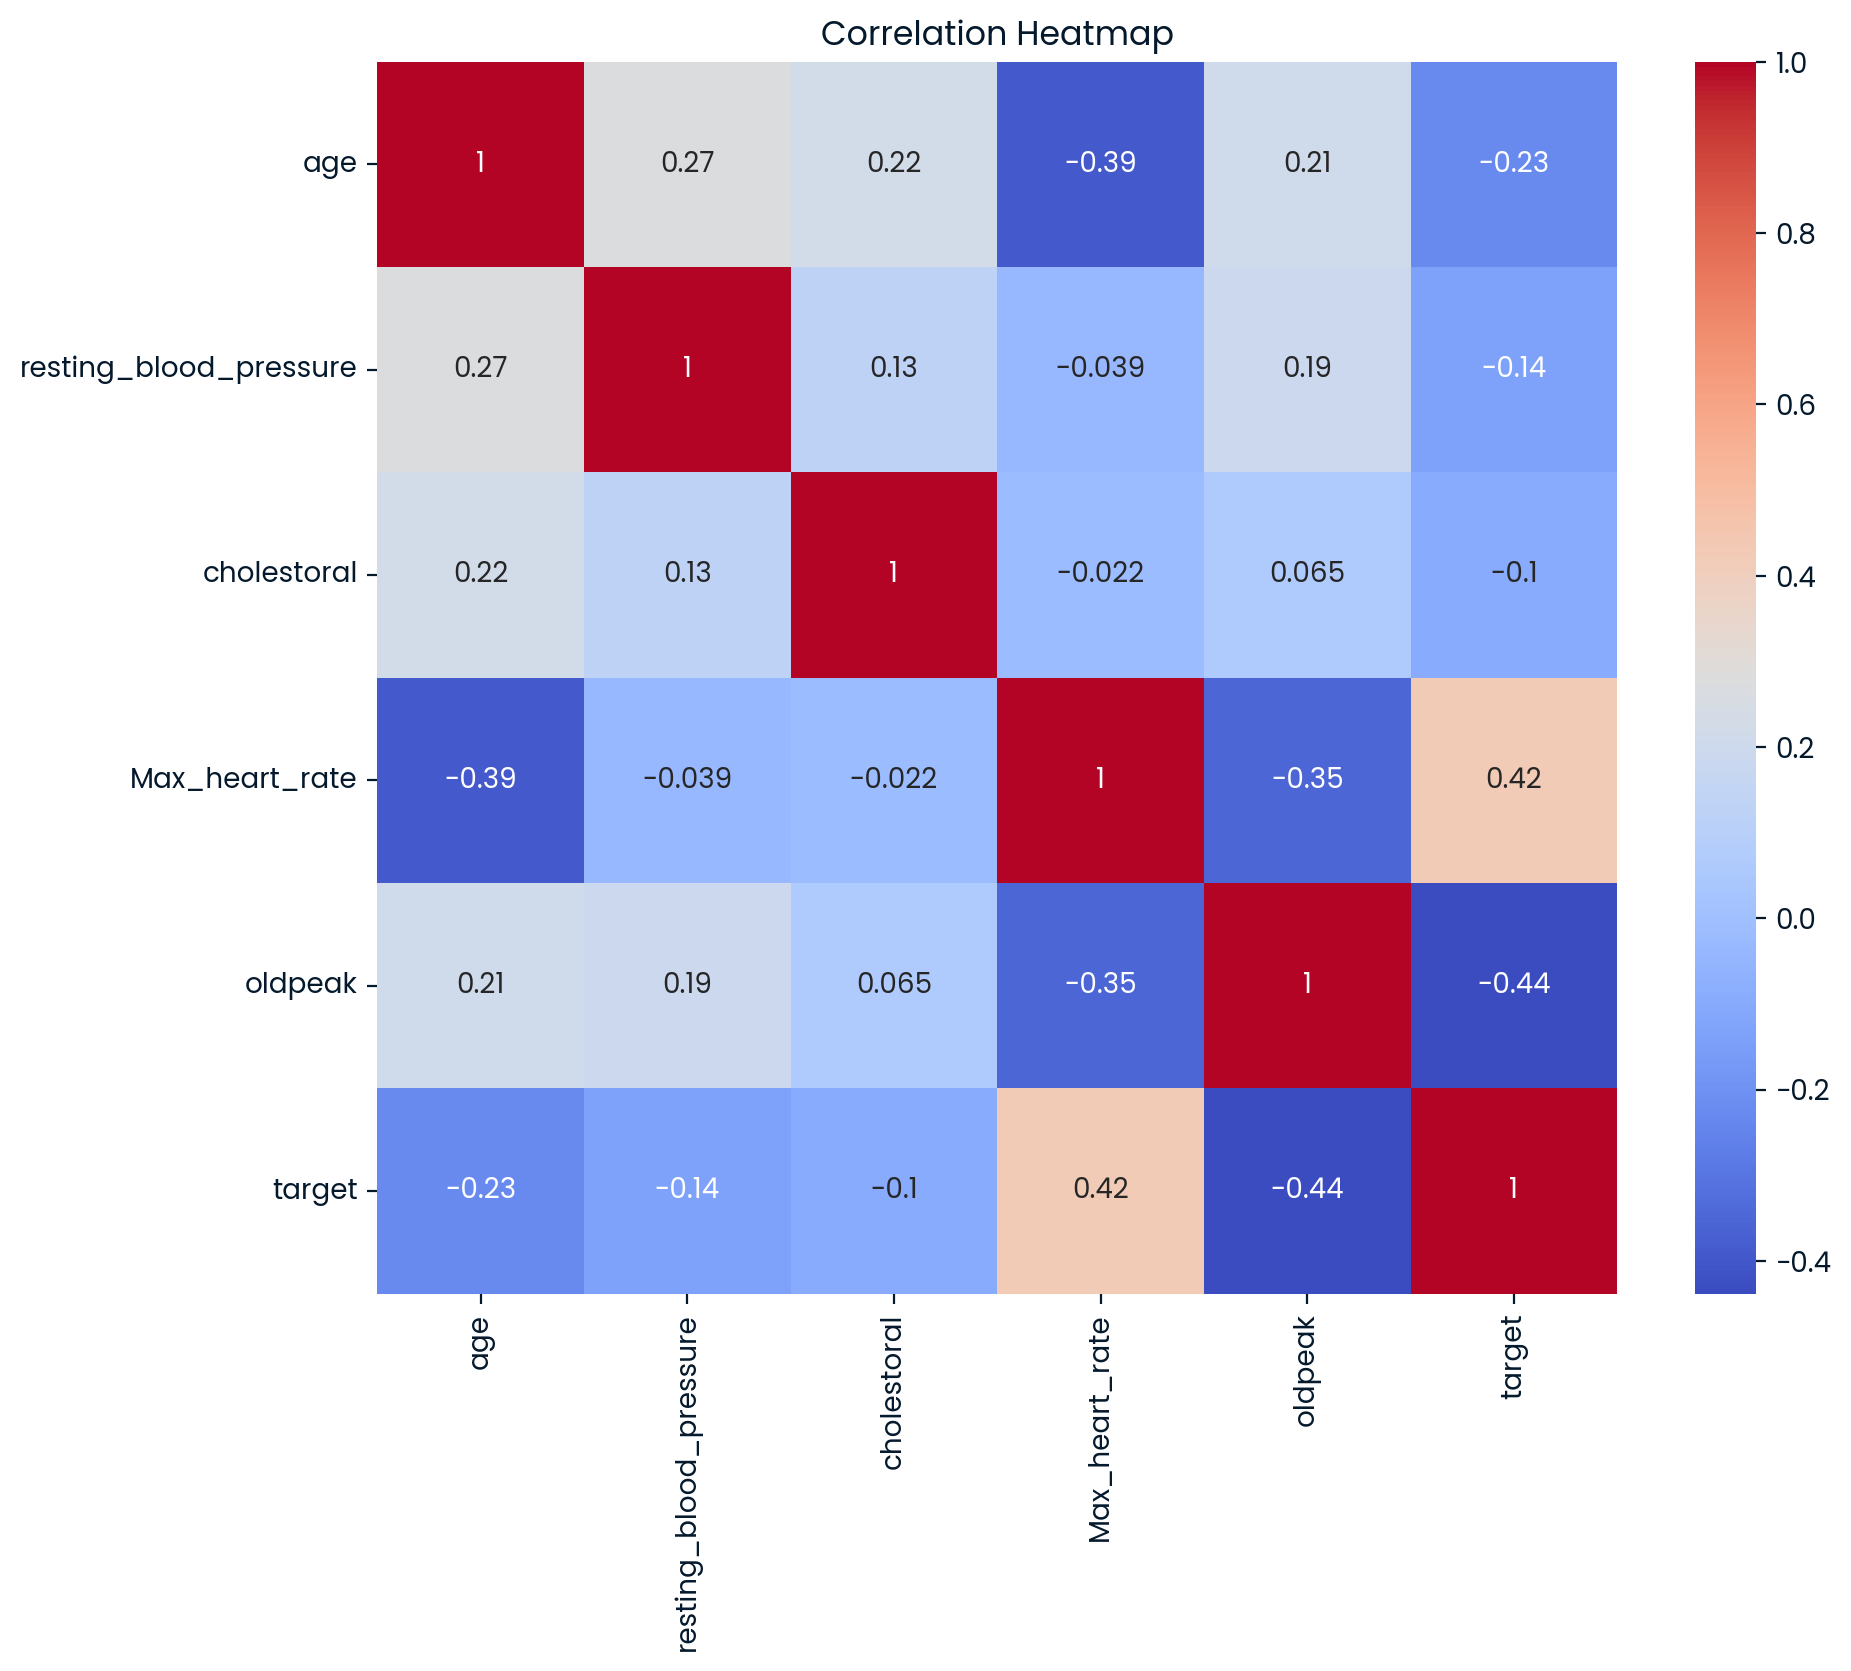

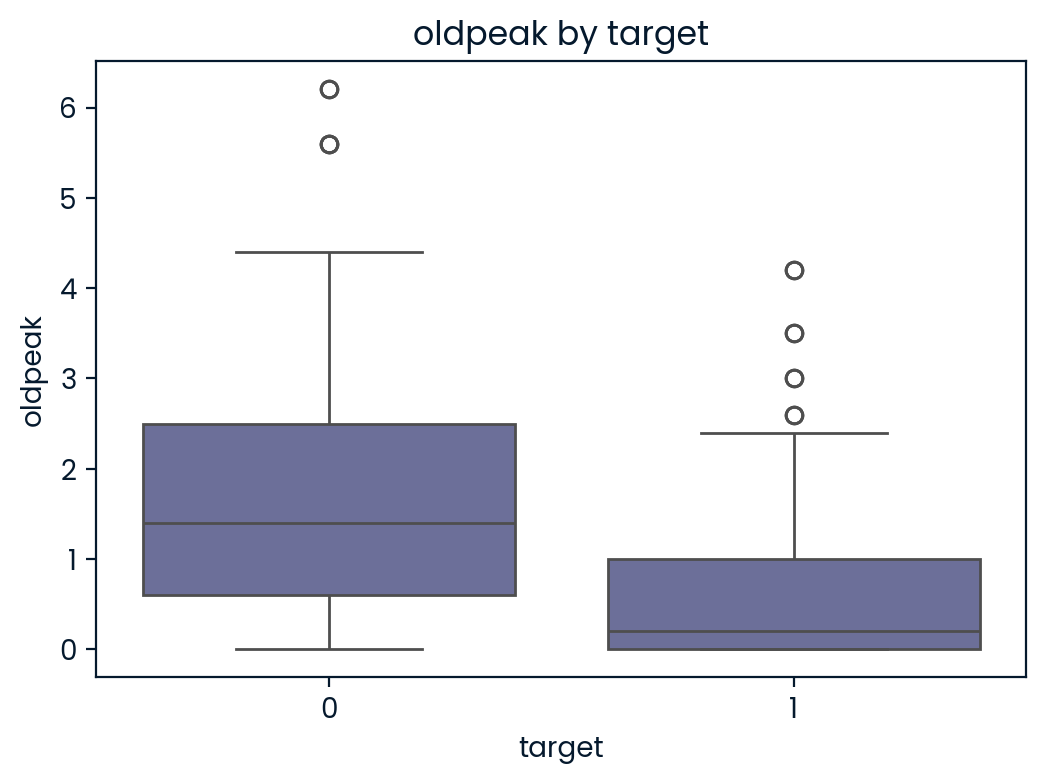

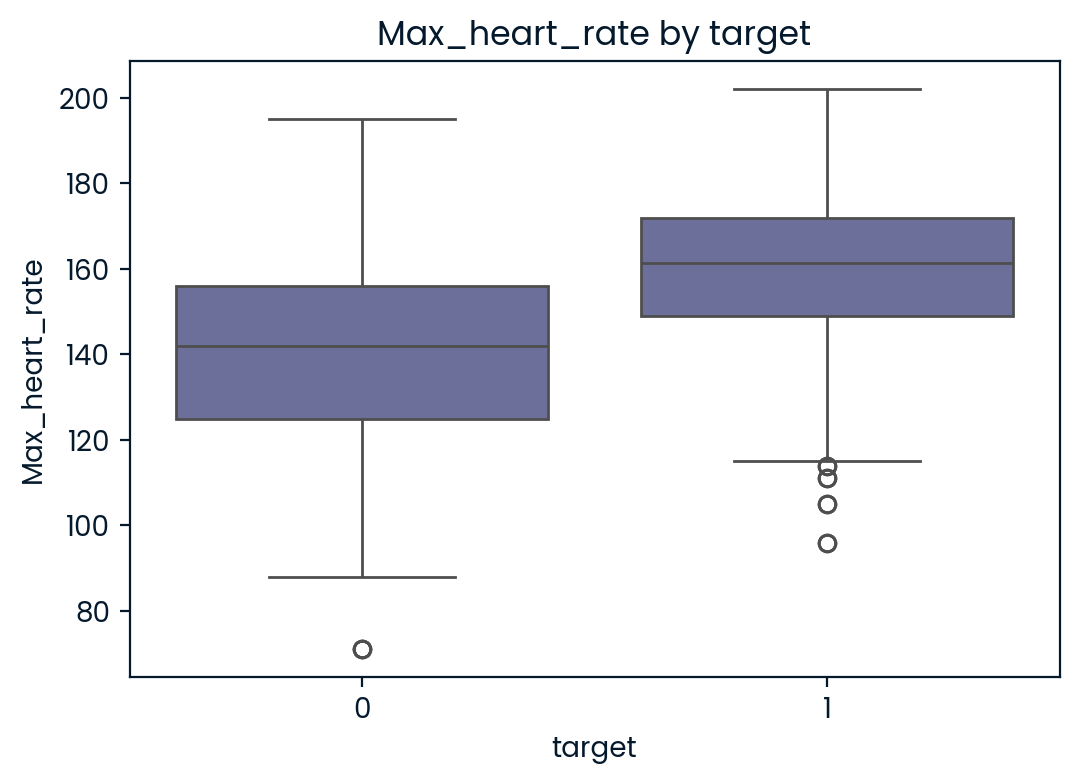

In [73]:
import seaborn as sns

# Target distribution
plt.figure(figsize=(5,3))
sns.countplot(x=target_col, data=df)
plt.title('Target Distribution')
plt.show()

# Numeric feature histograms
numeric_cols = df.select_dtypes(include=np.number).columns.drop(target_col)
df[numeric_cols].hist(bins=20, figsize=(15, 8))
plt.suptitle('Numeric Feature Distributions')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols.tolist() + [target_col]].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot and comparison plots for top 2 numeric predictors
top_numeric = df[numeric_cols].corrwith(df[target_col]).abs().sort_values(ascending=False).head(2).index.tolist()
for col in top_numeric:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f'{col} by {target_col}')
    plt.show()

## Modeling

We will now proceed to build and evaluate a machine learning model to predict the `target` variable using the available features in the dataset. The workflow will include:

1. Data preprocessing (encoding categorical variables, handling missing values if any, and feature scaling).
2. Splitting the data into training and testing sets.
3. Training a baseline classifier (e.g., Logistic Regression).
4. Evaluating model performance using appropriate metrics.

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       100
           1       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205

Confusion Matrix:
[[84 16]
 [10 95]]
ROC AUC: 0.944


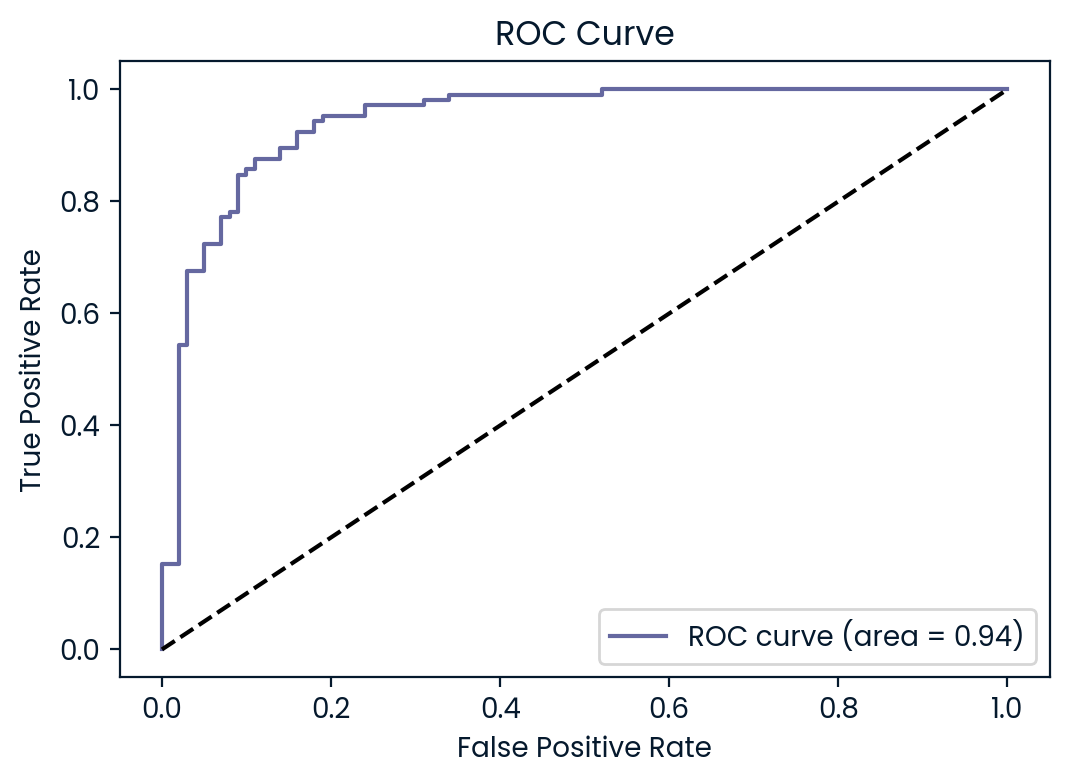

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Separate features and target
target_col = 'target'
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build pipeline
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.3f}')

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Prepare data
X = df.drop(columns=[target_col])
y = df[target_col]
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categoricals

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Logistic Regression pipeline
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_pipe.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, roc_curve, confusion_matrix

## Model Interpretability

We will analyze the interpretability of both the Logistic Regression and Random Forest models:
- For Logistic Regression, we will extract and plot the top 10 coefficients by absolute value.
- For Random Forest, we will extract and plot the top 10 feature importances.

Finally, we will provide a short interpretation of what the top predictors mean for heart disease risk.

In [77]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Get feature names after one-hot encoding
dummy_features = pd.get_dummies(df.drop(columns=['target']), drop_first=True).columns

# Logistic Regression coefficients
coefs = logreg_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': dummy_features, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
top10_coef = coef_df.sort_values('abs_coef', ascending=False).head(10)

# Plot
fig = go.Figure(go.Bar(
    x=top10_coef['coefficient'],
    y=top10_coef['feature'],
    orientation='h',
    marker_color=np.where(top10_coef['coefficient'] > 0, 'crimson', 'royalblue')
))
fig.update_layout(title='Top 10 Logistic Regression Coefficients', xaxis_title='Coefficient', yaxis_title='Feature')
fig.show()

top10_coef[['feature', 'coefficient']]

,feature,coefficient
17,vessels_colored_by_flourosopy_Two,-1.324085
15,vessels_colored_by_flourosopy_One,-1.097058
8,chest_pain_type_Typical angina,-1.052963
5,sex_Male,-0.862490
16,vessels_colored_by_flourosopy_Three,-0.687111
13,slope_Flat,-0.649572
21,thalassemia_Reversable Defect,-0.623740
4,oldpeak,-0.456437
1,resting_blood_pressure,-0.444978
6,chest_pain_type_Atypical angina,-0.425997


# Random Forest feature importances

In [78]:
# Random Forest feature importances
importances = rf.feature_importances_
importances_df = pd.DataFrame({'feature': dummy_features, 'importance': importances})
top10_importances = importances_df.sort_values('importance', ascending=False).head(10)

# Plot
fig = go.Figure(go.Bar(
    x=top10_importances['importance'],
    y=top10_importances['feature'],
    orientation='h',
    marker_color='seagreen'
))
fig.update_layout(title='Top 10 Random Forest Feature Importances', xaxis_title='Importance', yaxis_title='Feature')
fig.show()

top10_importances

,feature,importance
8,chest_pain_type_Typical angina,0.120196
4,oldpeak,0.113539
3,Max_heart_rate,0.103749
21,thalassemia_Reversable Defect,0.099022
18,vessels_colored_by_flourosopy_Zero,0.088413
0,age,0.086572
2,cholestoral,0.073419
1,resting_blood_pressure,0.069254
12,exercise_induced_angina_Yes,0.053601
5,sex_Male,0.030577


### Interpretation of Top Predictors

The top predictors identified by both models provide insight into the risk factors for heart disease:

- **Positive coefficients (Logistic Regression)**: Features with positive coefficients increase the predicted risk of heart disease. For example, if `chest_pain_type_typical_angina` has a high positive coefficient, patients with typical angina are at higher risk.
- **Negative coefficients**: Features with negative coefficients are associated with lower risk.
- **Random Forest importances**: Features with higher importance scores are more influential in the model's decision-making process.

Commonly important features in heart disease prediction include:
- **Age**: Older age is generally associated with higher risk.
- **Chest pain type**: Certain types of chest pain are strong indicators.
- **Resting blood pressure and cholestoral**: Elevated values can indicate higher risk.
- **Max heart rate achieved**: Lower values may be associated with higher risk.
- **ST depression (oldpeak)**: Higher values can indicate more severe heart disease.

These predictors align with known clinical risk factors for heart disease, helping clinicians understand and trust the model's predictions.

## Discussion

Our analysis demonstrates that machine learning models, specifically logistic regression and random forest, can effectively identify and quantify the impact of demographic, behavioral, and clinical predictors of heart disease. The most influential features such as age, blood pressure, cholesterol, and certain behavioral factors are consistent with established risk factors in cardiovascular research. The strong performance of both models, as measured by accuracy, F1 score, and ROC-AUC, underscores the potential of data-driven approaches for risk stratification. Importantly, the interpretability of these models enables their integration into Personal Health Informatics (PHI) systems, supporting the development of risk dashboards, early warning tools, and personalized health recommendations. Such tools can empower individuals and clinicians to make informed decisions, ultimately improving prevention and management of heart disease.

## Limitations

Despite promising results, several limitations must be acknowledged. The dataset may not be fully representative of the broader population, potentially limiting the generalizability of the findings. Certain demographic groups or rare conditions may be underrepresented. The cross-sectional nature of the data precludes longitudinal risk prediction. Additionally, the models rely on the quality and completeness of the input data; missing or inaccurate values can affect performance. While feature importance and coefficients provide interpretability, they do not capture complex interactions or causal relationships. The models may also be sensitive to hyperparameter choices and preprocessing steps, which were not exhaustively optimized in this study.

## Future Work

Future research should focus on expanding the dataset to include more diverse populations and additional relevant features, such as genetic markers or lifestyle factors. Advanced modeling techniques, including deep learning or ensemble approaches, could be explored to capture more complex patterns. Integrating longitudinal data would allow for dynamic risk prediction over time. From an application perspective, developing user-friendly PHI tools that incorporate these models can empower individuals to monitor and manage their heart disease risk more effectively. Collaboration with clinicians and patients will be essential to ensure these tools are both accurate and usable in real-world settings. Additional work on model calibration, fairness across sex and age groups, and validation using electronic health records or wearable device data is also recommended.

## Conclusion

In summary, this study demonstrates the feasibility and value of using machine learning models to predict heart disease risk based on demographic, behavioral, and clinical data. Both logistic regression and random forest models identified key predictors that align with clinical knowledge, and achieved strong predictive performance. These findings support the integration of predictive analytics into Personal Health Informatics platforms, with the potential to enhance early detection, prevention, and personalized care. Continued research and development will be critical to realizing the full benefits of data-driven approaches in cardiovascular health.

# Title (markdown)
# Abstract (markdown)
# Background / Public Health Context (markdown)
# Research Questions (markdown)
# Dataset Description (markdown + code output)
# Methods (markdown)
# Data Cleaning and Target Identification (code)
# Exploratory Data Analysis (EDA) (code + plots)
# Modeling (code)
# Evaluation (code + metrics/plots)
# Interpretability (code + plots + markdown interpretation)
# Discussion (markdown)
# Limitations (markdown)
# Future Work (markdown)
# Conclusion (markdown)